In [1]:
from functools import reduce

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
_grad_data = []
for i in range(2):
    for j in range(79):
        print(f'Loading worker {1} epoch {i} batch {j}')
        with np.load(f'exp_data/gradients/worker_{1}/grads_epoch_{i}_batch_{j}.npz') as data:
            g = [data[key].astype(np.float16).flatten() 
                            for key in data.files[::2][:]]
            [gg.sort() for gg in g]
            _grad_data.append(g)
_grad_data=[np.sort(np.concatenate(gg)) for gg in zip(*_grad_data)]

Loading worker 1 epoch 0 batch 0
Loading worker 1 epoch 0 batch 1
Loading worker 1 epoch 0 batch 2
Loading worker 1 epoch 0 batch 3
Loading worker 1 epoch 0 batch 4
Loading worker 1 epoch 0 batch 5
Loading worker 1 epoch 0 batch 6
Loading worker 1 epoch 0 batch 7
Loading worker 1 epoch 0 batch 8
Loading worker 1 epoch 0 batch 9
Loading worker 1 epoch 0 batch 10
Loading worker 1 epoch 0 batch 11
Loading worker 1 epoch 0 batch 12
Loading worker 1 epoch 0 batch 13
Loading worker 1 epoch 0 batch 14
Loading worker 1 epoch 0 batch 15
Loading worker 1 epoch 0 batch 16
Loading worker 1 epoch 0 batch 17
Loading worker 1 epoch 0 batch 18
Loading worker 1 epoch 0 batch 19
Loading worker 1 epoch 0 batch 20
Loading worker 1 epoch 0 batch 21
Loading worker 1 epoch 0 batch 22
Loading worker 1 epoch 0 batch 23
Loading worker 1 epoch 0 batch 24
Loading worker 1 epoch 0 batch 25
Loading worker 1 epoch 0 batch 26
Loading worker 1 epoch 0 batch 27
Loading worker 1 epoch 0 batch 28
Loading worker 1 epoch 0

In [3]:
k=[20,100,20,20,20]
temp=[np.max([gg[i::k[j]].shape[0] for i in range(k[j])]) for j, gg in enumerate(_grad_data)]
f=lambda x, max_shape: np.concatenate([x,np.array( [x[-1]]*(max_shape-len(x)) )]) if max_shape>len(x) else x

grad_data=[
    np.sum([f(gg[i::k[j]], temp[j]) for i in range(k[j])], axis=0) 
    for j, gg in enumerate(_grad_data)
]
all_grads=np.concatenate([grad_data[i].flatten() for i in range(len(grad_data))])

In [4]:
plt.figure(figsize=(15, 10))
sns.histplot(all_grads, bins=1000, label=f'all grads', kde=True)
plt.title('all grads')
plt.show()

NameError: name 'all_grads' is not defined

<Figure size 1500x1000 with 0 Axes>

In [21]:
# save all grads
np.savez_compressed(f'exp_data/gradients/all_grads.npz', all_grads=all_grads)

In [4]:
g_shapes = [gg.shape for gg in grad_data]
g_shapes

[(6826,), (6627001,), (517735,), (64717,), (5056,)]

In [5]:
all_grads = np.clip(all_grads, *np.percentile(all_grads, [0.05, 99.95]))
grad_data = [np.clip(grad_data[i], *np.percentile(grad_data[i], [0.05, 99.95])) for i in range(len(grad_data))]

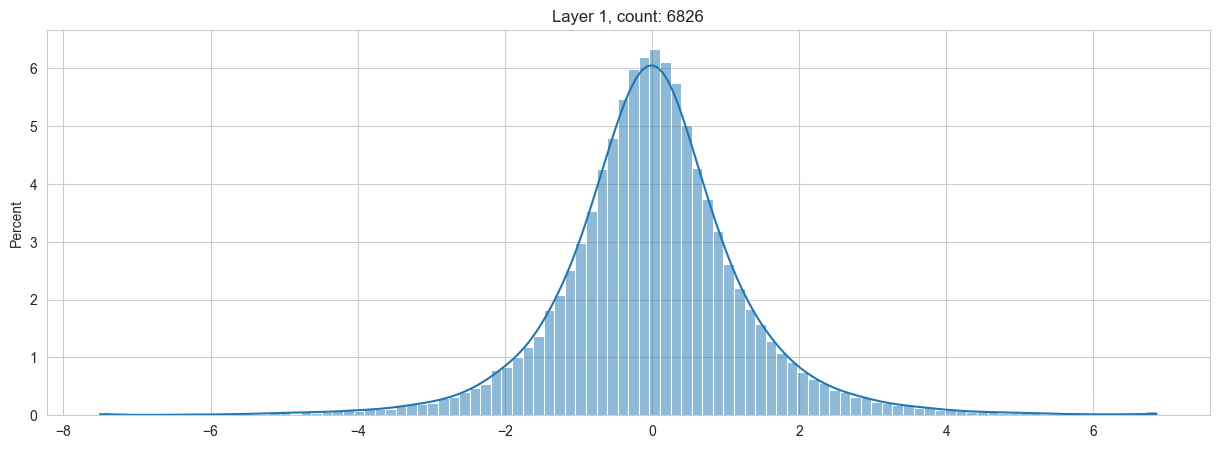

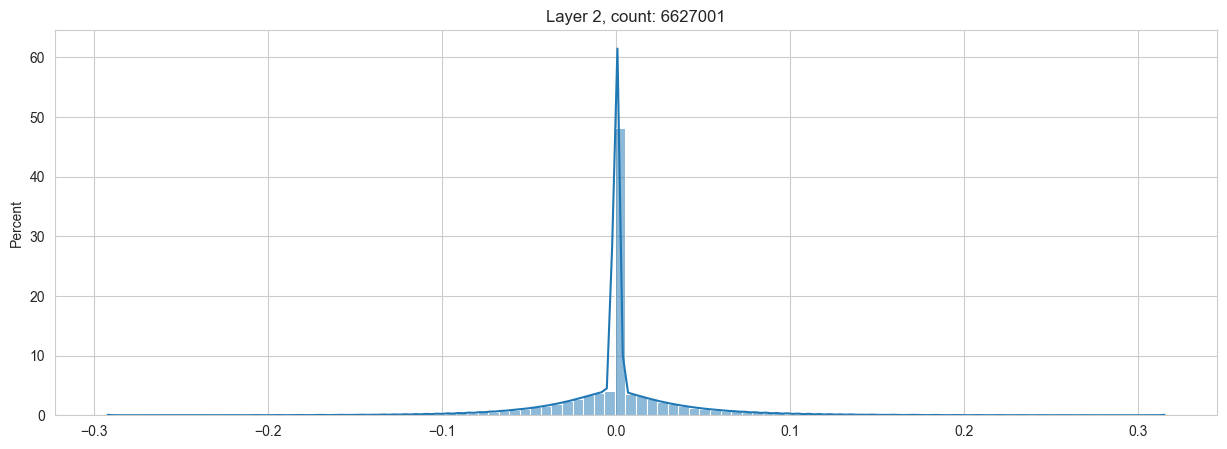

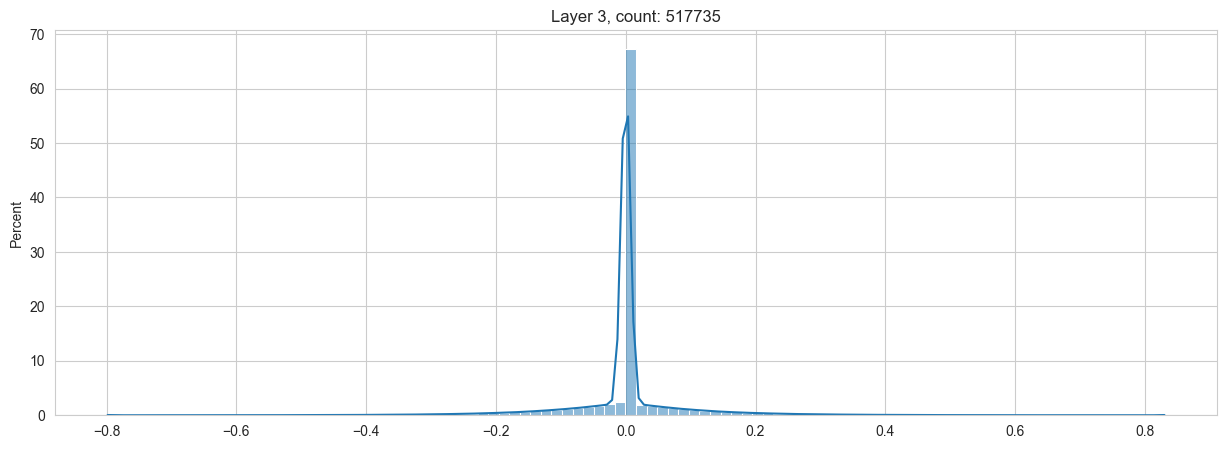

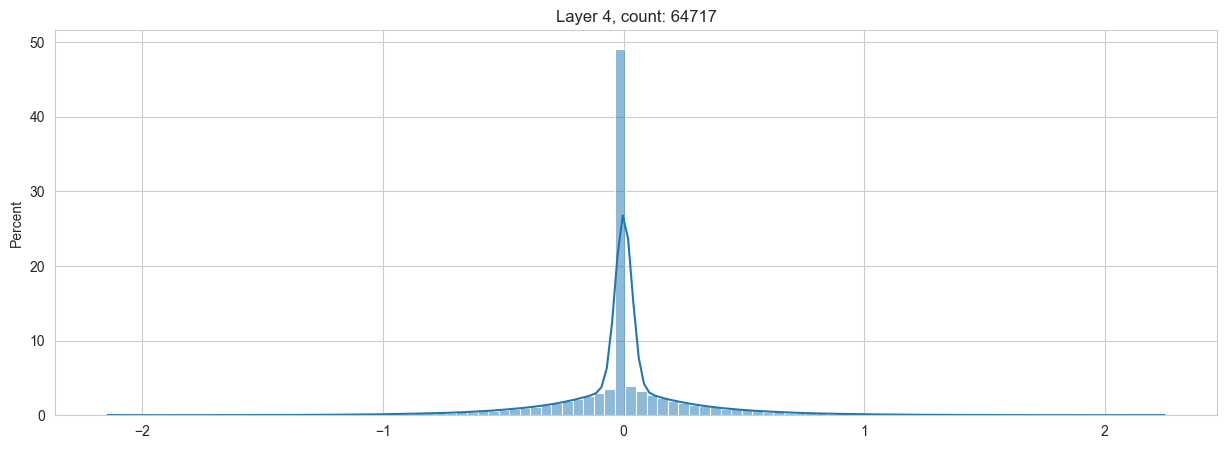

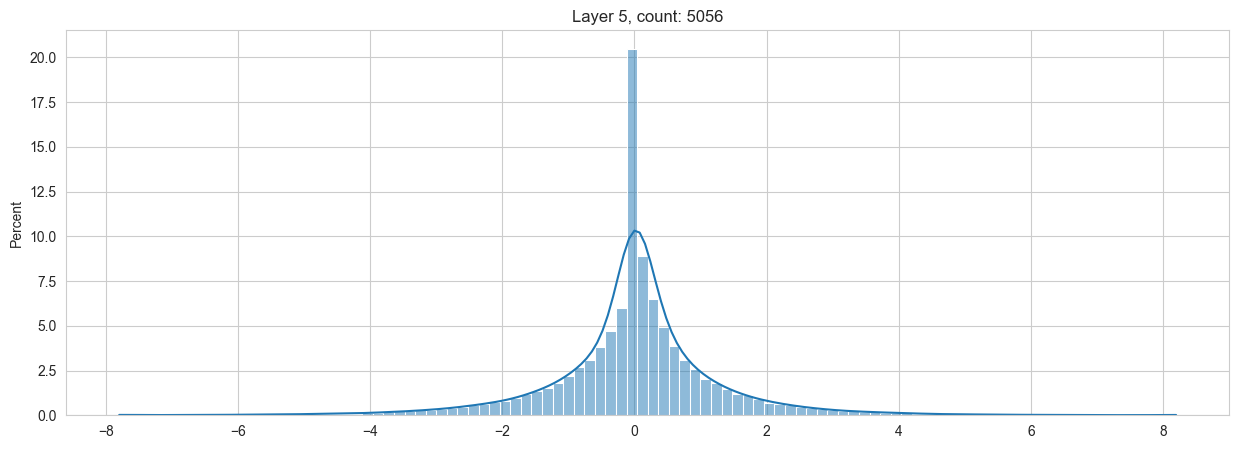

In [6]:
for i in range(len(grad_data)):
    plt.figure(figsize=(15, 5))
    sns.histplot((grad_data[i].flatten()), bins=100, label=f'Layer {i+1}', kde=True, stat='percent')
    plt.title(f'Layer {i+1}, count: {grad_data[i].shape[0]}')
    plt.show()

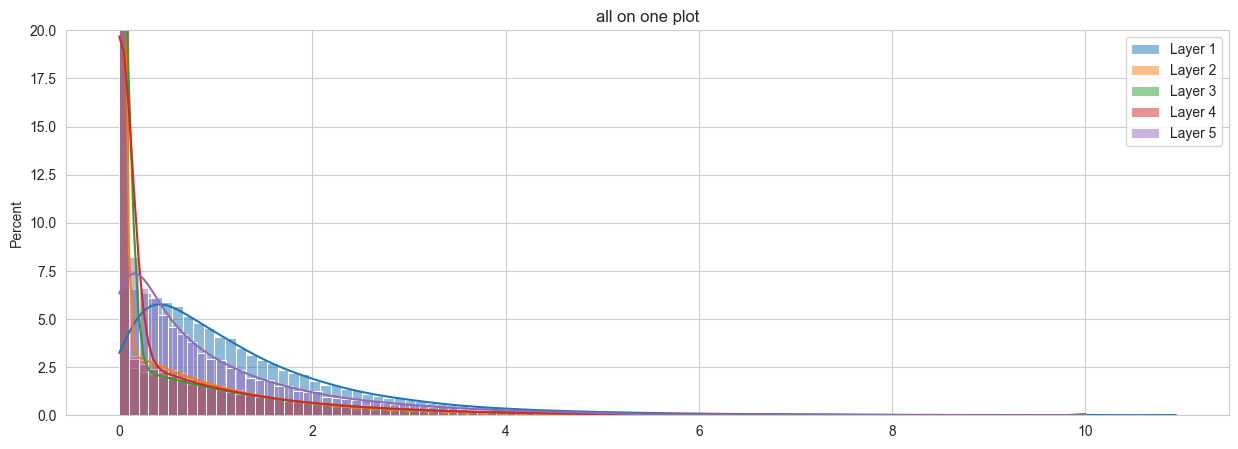

In [16]:
plt.figure(figsize=(15, 5))
for i in range(len(grad_data)):
    temp=grad_data[i].flatten()
    temp=np.abs(temp/np.max(temp))*10
    zero_count=temp[temp==0].shape[0]
    if zero_count/temp.shape[0] > 0.1:
        temp=temp[int(zero_count-temp.shape[0]*0.9):]
    sns.histplot((temp), bins=100, label=f'Layer {i+1}', kde=True, stat='percent')
    plt.title(f'all on one plot')
plt.ylim(0, 20)
plt.legend()
plt.show()

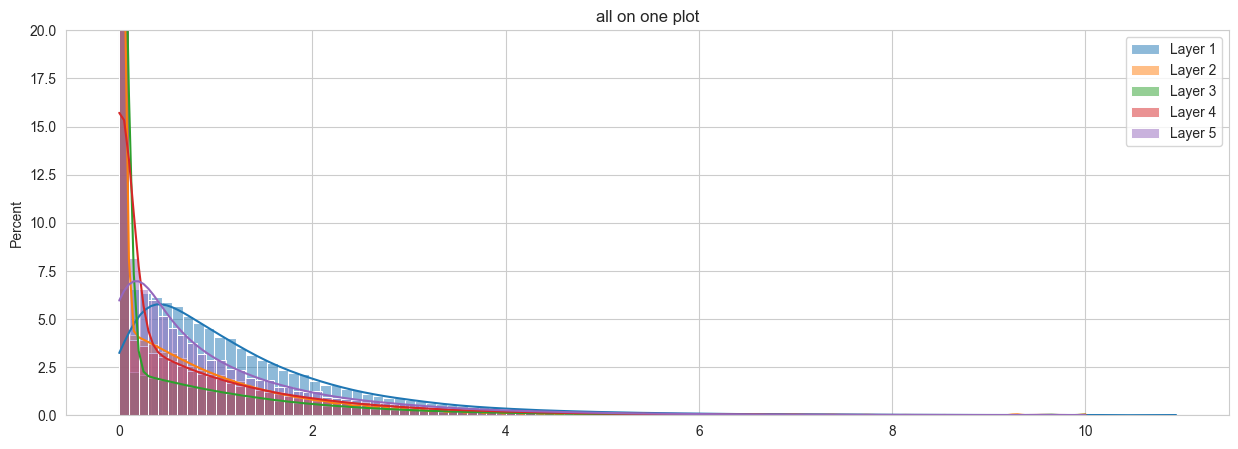

In [17]:
plt.figure(figsize=(15, 5))
for i in range(len(grad_data)):
    temp=grad_data[i].flatten()
    temp=np.abs(temp/np.max(temp))*10
    # zero_count=temp[temp==0].shape[0]
    # if zero_count/temp.shape[0] > 0.1:
    #     temp=temp[zero_count-temp.shape[0]*0.1:]
    sns.histplot((temp), bins=100, label=f'Layer {i+1}', kde=True, stat='percent')
    plt.title(f'all on one plot')
plt.ylim(0, 20)
plt.legend()
plt.show()

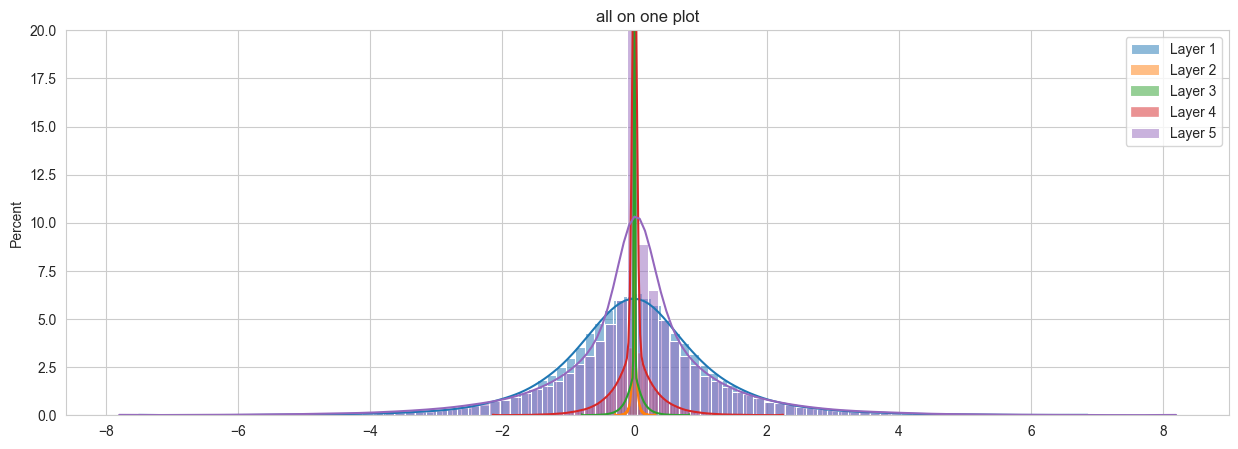

In [8]:
plt.figure(figsize=(15, 5))
for i in range(len(grad_data)):
    temp=grad_data[i].flatten()
    sns.histplot((temp), bins=100, label=f'Layer {i+1}', kde=True, stat='percent')
    plt.title(f'all on one plot')
plt.ylim(0, 20)
plt.legend()
plt.show()

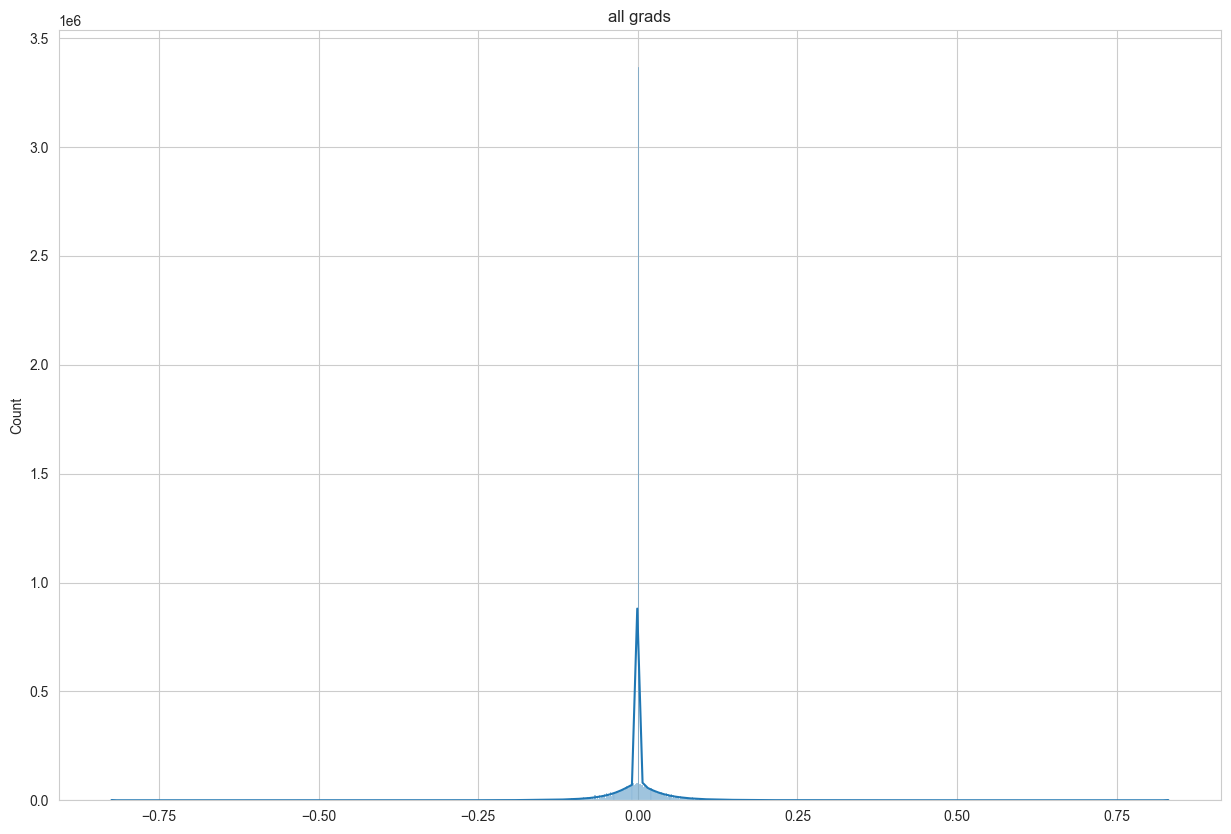

In [19]:
plt.figure(figsize=(15, 10))
sns.histplot((all_grads), bins=1000, label=f'all grads', kde=True)
plt.title('all grads')
plt.show()

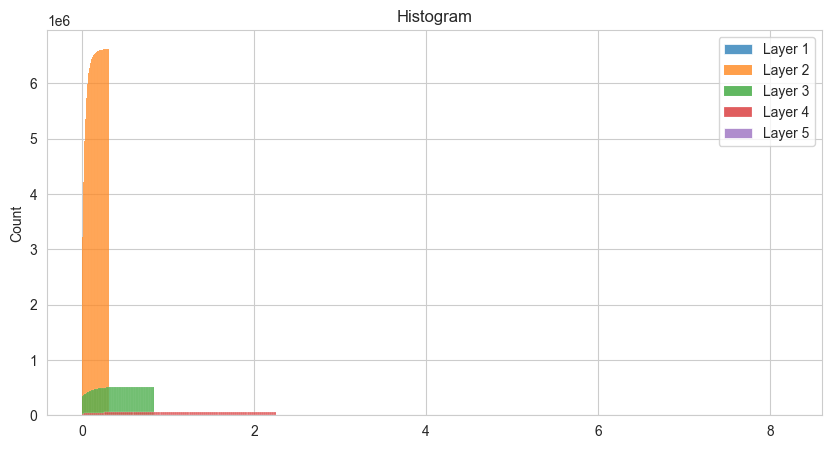

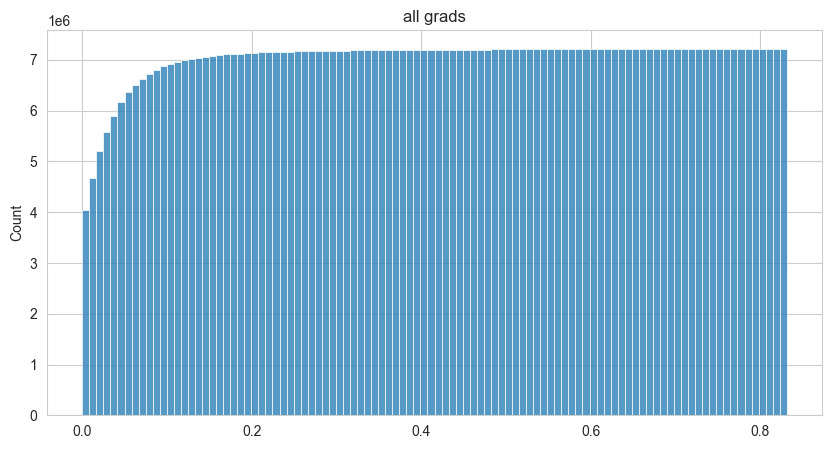

In [10]:
plt.figure(figsize=(10, 5))
for i in range(len(grad_data)):
    sns.histplot(np.abs(grad_data[i].flatten()), bins=100, label=f'Layer {i+1}', cumulative=True)
plt.title('Histogram')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.abs(all_grads), bins=100, label=f'all grads', cumulative=True)
plt.title('all grads')
plt.show()

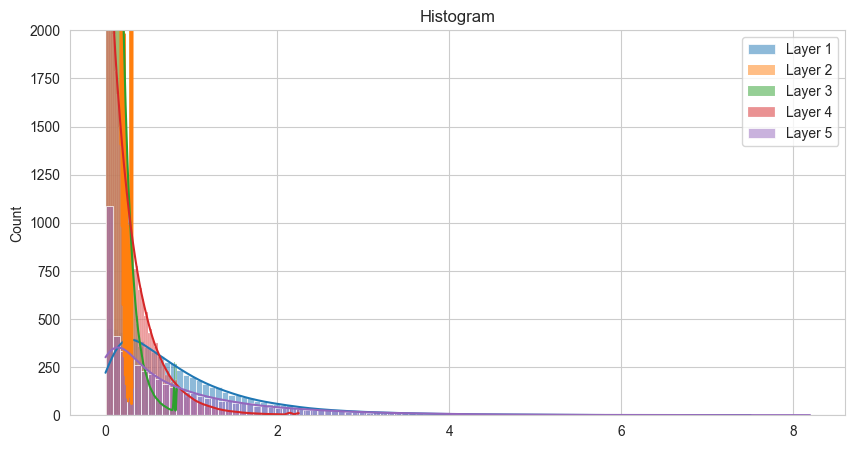

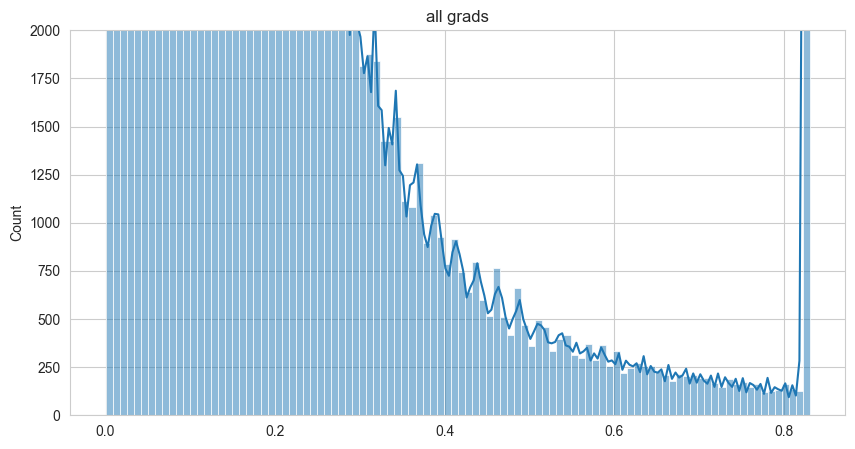

In [11]:
temp=2000

plt.figure(figsize=(10, 5))
for i in range(len(grad_data)):
    sns.histplot(np.abs(grad_data[i].flatten()), bins=100, label=f'Layer {i+1}', kde=True)
plt.title('Histogram')
plt.ylim(0, temp)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.abs(all_grads), bins=100, label=f'all grads', kde=True)
plt.title('all grads')
plt.ylim(0, temp)
plt.show()

In [ ]:
all_grads = np.sort(np.abs(np.concatenate(_grad_data)))

In [7]:
data = np.random.choice(all_grads, size=100000, replace=False)

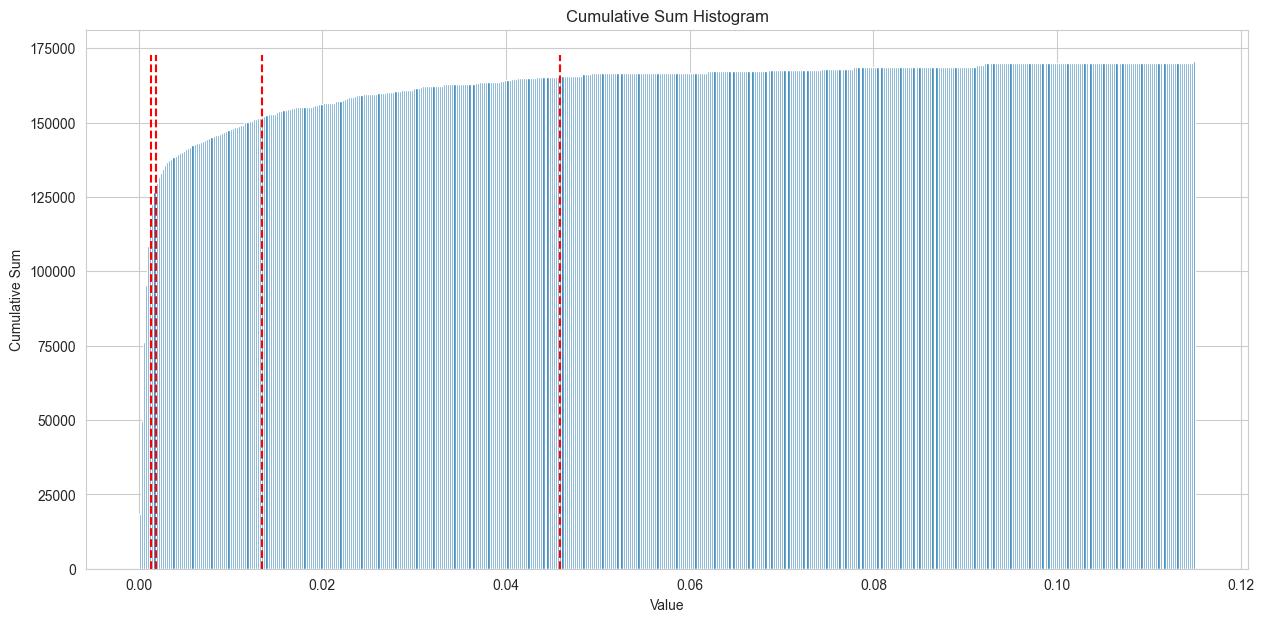

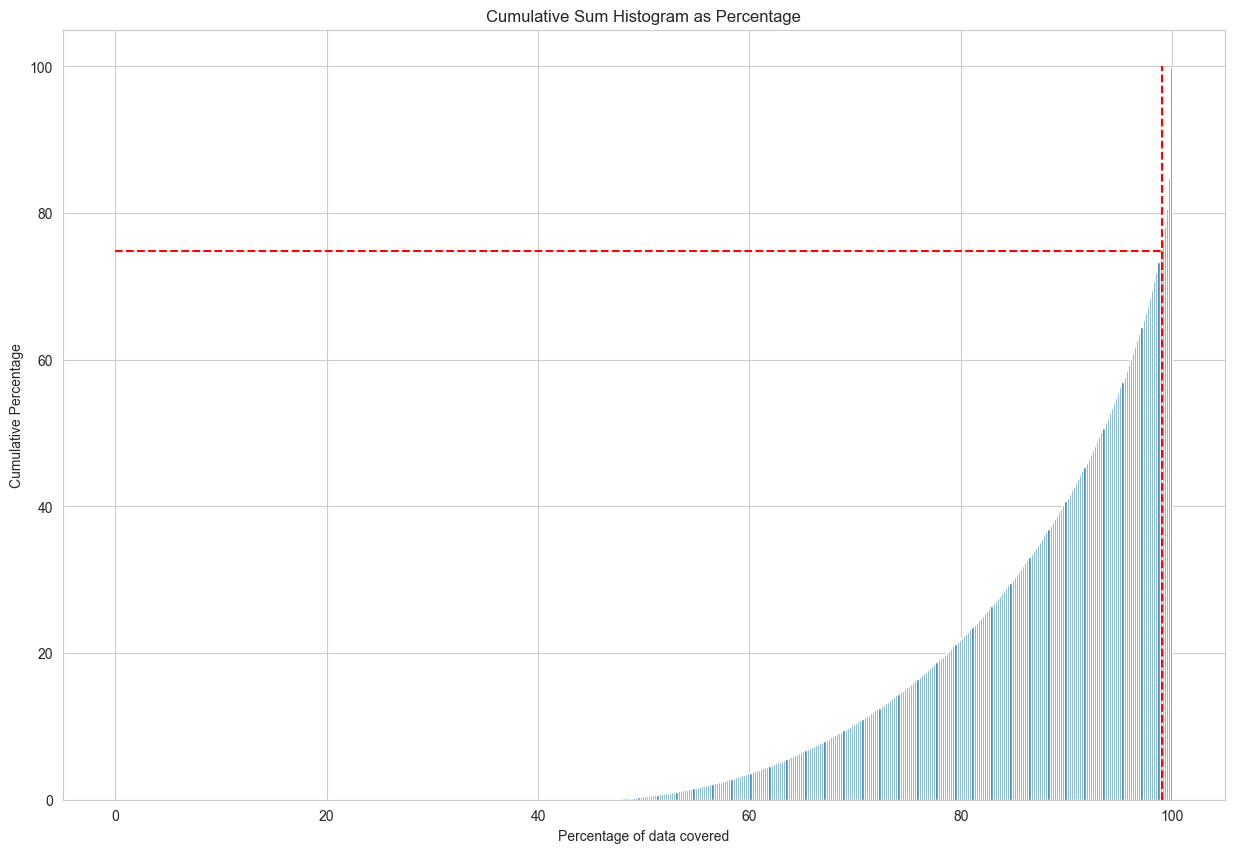

In [8]:
import numpy as np
import matplotlib.pyplot as plt

scaling = len(all_grads) / len(data)
figure, ax = plt.subplots(figsize=(15, 7))
temp_v = np.sum(data)*len(all_grads)/len(data)*1.01
plt.hist(data, bins=500, cumulative=True, weights=data*scaling)
plt.vlines(x=np.percentile(data, [98,99,99.9,99.99]), ymin=0, ymax=temp_v, color='r', linestyle='--')
plt.xlabel("Value")
plt.ylabel("Cumulative Sum")
plt.title("Cumulative Sum Histogram")
plt.show()

import numpy as np
import matplotlib.pyplot as plt

sorted_indices = np.argsort(data)
percent_data = np.empty_like(data, dtype=float)
percent_data[sorted_indices] = np.linspace(0, 100, len(data))

total_sum = np.sum(data) * scaling
weights_percentage = data * scaling / total_sum * 100

figure, ax = plt.subplots(figsize=(15, 10))
ax.hist(percent_data, bins=500, cumulative=True, weights=weights_percentage, color='C0')

perc_value = 99
ax.vlines(x=perc_value, ymin=0, ymax=100, color='r', linestyle='--')

# Correct: compute cumulative sum up to the 99th percentile
threshold = np.percentile(data, perc_value)
temp_v = np.sum(data[data <= threshold]) * scaling / total_sum * 100
ax.hlines(y=temp_v, xmin=0, xmax=perc_value, color='r', linestyle='--')

ax.set_xlabel("Percentage of data covered")
ax.set_ylabel("Cumulative Percentage")
ax.set_title("Cumulative Sum Histogram as Percentage")
plt.show()